In [37]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV, train_test_split
from scipy.stats import binomtest, ttest_ind, chi2_contingency
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

df = pd.read_csv("train_data.csv")
train_set, test_set = train_test_split(df, test_size=0.2, random_state=42)
train_set.head()

,ID,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
91348,108635,15606267,Wilson,622,France,Female,35.0,7,98640.74,2,1.0,1.0,110457.99,1
2636,147941,15644891,Pirozzi,752,France,Female,32.0,2,0.00,1,1.0,0.0,159843.24,0
117007,88744,15702464,Watson,710,France,Male,31.0,4,0.00,3,0.0,0.0,160548.66,1
100279,125789,15701605,L?,704,Germany,Male,46.0,4,138912.17,1,0.0,1.0,141804.78,1
34835,135997,15757577,Hs?,675,Germany,Female,51.0,8,143390.51,1,1.0,0.0,168034.90,1


In [38]:
train_set["Exited"].value_counts()

Exited
0    90564
1    24299
Name: count, dtype: int64

On voit que les deux classes de la target sont assez désiquilibré et c'est pour cette raison qu'on utilisera la métrique f1_score.

#I) Définition des variables et des lignes

•   Customer ID : Un identifiant unique pour chaque client (discret). Inutile pour le modéle.

•   Surname : Le nom de famille du client (discret). Inutile pour le modéle.

•   Credit Score : Une valeur numérique représentant le score de crédit du client (continue)

•   Geography : Le pays où réside le client (France, Spain ou Germany) (discret)

•   Gender : Le genre du client (Male or Female) (discret)

•   Age : L’âge du client (C'est une variable discréte mais qu'on va traiter comme une variable continue)

•   Tenure : Le nombre d’années pendant lesquelles le client est avec la banque (discret)

•   Balance : Le solde du compte du client (continue)

•   NumOfProducts : Le nombre de produits bancaires utilisés par le client (par exemple, compte d’épargne, carte de crédit) (discret)

•   HasCrCard : Si le client possède une carte de crédit (1 = oui, 0 = non) (discret)

•   IsActiveMember : Si le client est un membre actif (1 = oui, 0 = non) (discret)

•   EstimatedSalary : Le salaire estimé du client (continue)

•   Exited : Si le client a résilié (1 = oui, 0 = non) (discret)

•   Pour la définition des lignes, c'est les clients.

#II) Analyse statistiques

Dans cette analyse on va d'abords faire des analyses univariés de chaque variable puis bivariés avec chaque variables en fonction de la target puis on regardera les surface séparables.

#II.1) Analyse univarié de toutes les variables

#II.1.1) Analyse du score de crédit.

Le score de crédit est un indicateur de la capacité d'un client de payer ces dettes. Plus ce score est bas, plus le client n'est pas fiable. L'échelle et l'interprétation de ce score dépends du pays mais aussi de la banque.

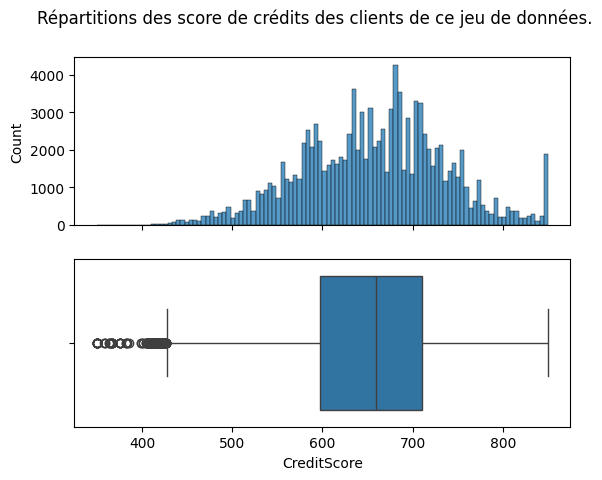

count    114863.000000
mean        656.504087
std          80.183550
min         350.000000
25%         597.000000
50%         659.000000
75%         710.000000
max         850.000000
Name: CreditScore, dtype: float64

In [39]:
fig, ax = plt.subplots(2, 1, sharex=True)
plt.suptitle("Répartitions des score de crédits des clients de ce jeu de données.")
sns.histplot(data=train_set, x="CreditScore", ax=ax[0])
sns.boxplot(data=train_set, x="CreditScore", ax=ax[1])
plt.show()
train_set["CreditScore"].describe()

On observe que la moyenne des clients qui vive en France, Allemagne et Espagne est d'environ 656. On observe que les score de crédit suive clairement une loi normale. On observe quelque outliers à gauche de la boxplot qui correspond donc au client les moins fiables. On voit aussi que la plupart des clients ont un crédit de score entre 580 et 750. C'est-à-dire que la plupart des clients ont un score de crédit plutôt moyen.


#II.1.2) Analyse du pays de résidence

On va d'abord compter le nombre de client par pays de résidence.  

In [40]:
train_set["Geography"].value_counts()

Geography
France     65494
Spain      25293
Germany    24076
Name: count, dtype: int64

On voit que la plupart des clients vive en France. Ensuite il y a un nombre similaire de client qui vive en Espagne et en Allemagne avec légéremment plus de client en Espagne qu'en Allemagne.

#II.1.3) Analyse du genre

In [41]:
train_set["Gender"].value_counts()

Gender
Male      64865
Female    49998
Name: count, dtype: int64

On voit qu'il y a plus d'homme que de femme dans cette banque.

#II.1.4) Analyse de l'âge

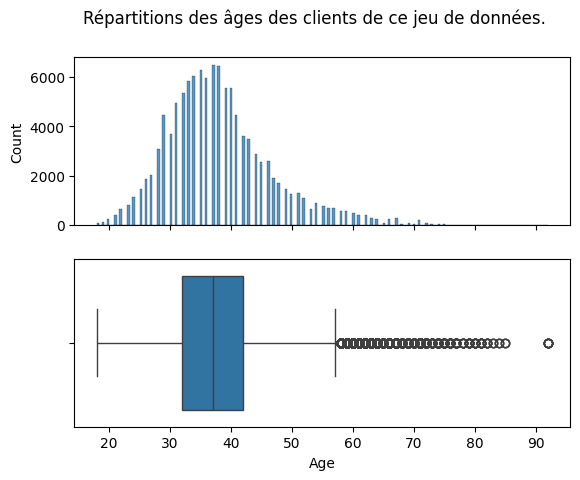

count    114863.000000
mean         38.143017
std           8.869733
min          18.000000
25%          32.000000
50%          37.000000
75%          42.000000
max          92.000000
Name: Age, dtype: float64

In [42]:
fig, ax = plt.subplots(2, 1, sharex=True)
plt.suptitle("Répartitions des âges des clients de ce jeu de données.")
sns.histplot(data=train_set, x="Age", ax=ax[0])
sns.boxplot(data=train_set, x="Age", ax=ax[1])
plt.show()
train_set["Age"].describe()

On voit que la moyenne d'âge des clients de la banque qui vivent en France, Allemagne et Espagne est de 38 ans. On voit que l'âge suit une loi normale et il y a des outliers à droite de la boxplot. On voit que la plupart des clients ont entre 30 et 40 ans.

#II.1.5) Analyse de la tenure

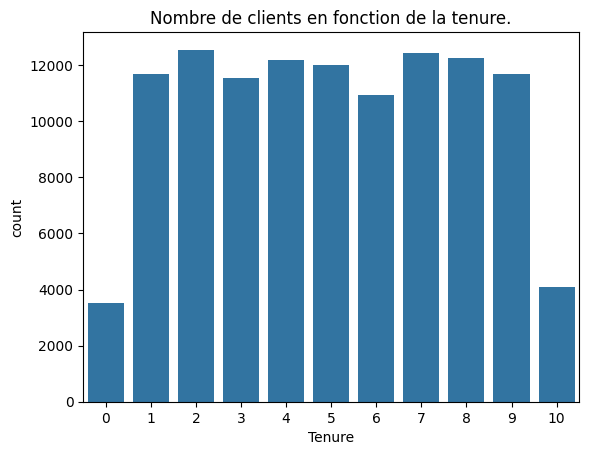

In [43]:
sns.countplot(data=train_set, x="Tenure")
plt.title("Nombre de clients en fonction de la tenure.")
plt.show()

On voit que dans la premiére année de cette banque (Tenure = 10), il y avait une quantité de client qui étais assez petites. Ensuite durant la deuxiéme (Tenure = 9), il y avait une grosse augmentation de la fréquentation de la banque et ensuite la fréquentation est relativement constante entre la deuxiéme année et la dixiéme année (Tenure = 1). Et ensuite durant l'année en cours il y a une diminution du nombre de client. Cela veut dire soit que la banque est moins attractive ou c'est tous simplement due au fait que l'année est en cours.

#II.1.6) Balance

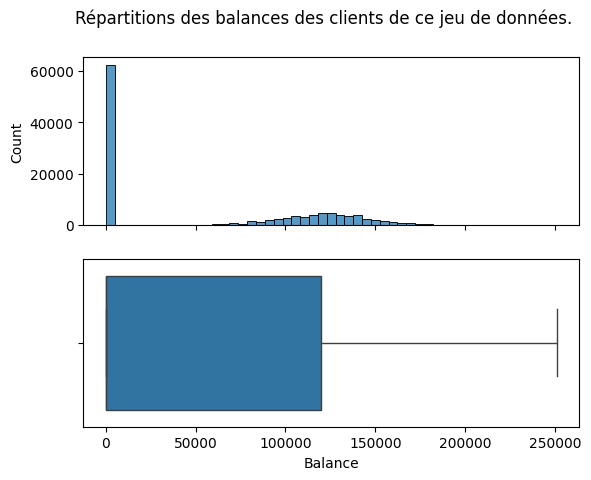

count    114863.000000
mean      55624.554866
std       62825.062047
min           0.000000
25%           0.000000
50%           0.000000
75%      120037.960000
max      250898.090000
Name: Balance, dtype: float64

In [44]:
fig, ax = plt.subplots(2, 1, sharex=True)
plt.suptitle("Répartitions des balances des clients de ce jeu de données.")
sns.histplot(data=train_set, x="Balance", ax=ax[0])
sns.boxplot(data=train_set, x="Balance", ax=ax[1])
plt.show()
train_set["Balance"].describe()

On voit que la plupart des clients ont une balance égale à 0. On voit qu'il y a une loi normale séparer des balances égales à 0. Pas d'outliers sur la boxplot. La moyenne de la balance des clients de cette banque pour les trois pays du jeu de données est d'environ 55728.70 euros.

#II.1.7) NumOfProducts

In [45]:
train_set["NumOfProducts"].value_counts()

NumOfProducts
2    58603
1    53910
3     2027
4      323
Name: count, dtype: int64

On voit que la plupart des clients ont 1 ou 2 produits et qu'il y a vraiment peu de cients qui ont 3 et 4 produit.

#II.1.8) HasCrCard

In [46]:
train_set["HasCrCard"].value_counts()

HasCrCard
1.0    86716
0.0    28147
Name: count, dtype: int64

On voit que la majorité des clients ont une carte de crédit.

#II.1.9) IsActiveMember

In [47]:
train_set["IsActiveMember"].value_counts()

IsActiveMember
0.0    57771
1.0    57092
Name: count, dtype: int64

On voit qu'il y a pratiquement autant de clients actifs que non actif. On peut donc tester cette hypothése.

In [48]:
print("H0: Il y a 50% de clients inactif.")

alpha = 0.02

p_value = binomtest(k=train_set["IsActiveMember"].value_counts()[1], n=len(train_set), p = 0.50).pvalue

if p_value < alpha:
    print("Nous avons assez d'évidence pour rejeter H0")
else:
    print("Nous n'avons pas assez d'évidence pour rejeter H0.")

H0: Il y a 50% de clients inactif.
Nous n'avons pas assez d'évidence pour rejeter H0.


Comme on n'a réussi de rejeter H0, on peut donc dire avec un risque de 2% de se trompé qu'il y a autant de client actif que inactif dans cette banque.

#II.1.10) Salaire

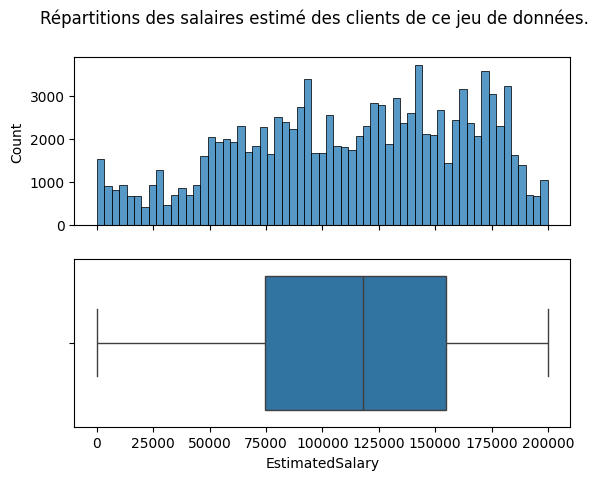

count    114863.000000
mean     112487.446654
std       50294.787529
min          11.580000
25%       74564.365000
50%      117832.880000
75%      154874.095000
max      199992.480000
Name: EstimatedSalary, dtype: float64

In [49]:
fig, ax = plt.subplots(2, 1, sharex=True)
plt.suptitle("Répartitions des salaires estimé des clients de ce jeu de données.")
sns.histplot(data=train_set, x="EstimatedSalary", ax=ax[0])
sns.boxplot(data=train_set, x="EstimatedSalary", ax=ax[1])
plt.show()
train_set["EstimatedSalary"].describe()

On voit que la moyenne des salaires estimé des clients de cette banque est de 112423 euros. Cette variable ne suit pas une loi normale. On observe aussi que le salaire minimum est de 11.58 qui correspond au smic horaire Français (environ égale à 1709 euros). Il faut savoir que les salaires estimé sont généralement des salaires mensuel et à temps plein. On voit que la plupart des salaires sont entre 40000 euros et 180000 euros ce qui est aussi bizarre pour des salaires mensuel. Il y a donc plusieurs types de salaires. On va donc dans la partie feature engineering faire cette correction. 

#II.2) Analyse multivarié.

Avant de commencé l'analyse bivarié, on peut catégoriser les variables en trois catégorie, les variables démographique, les variables monétaires et les variables de fidélité.

#II.2.1) Analyse des variables démographiques

Dans ce type variable, il y a trois variable qui sont le pays de résidence, le genre et l'âge.

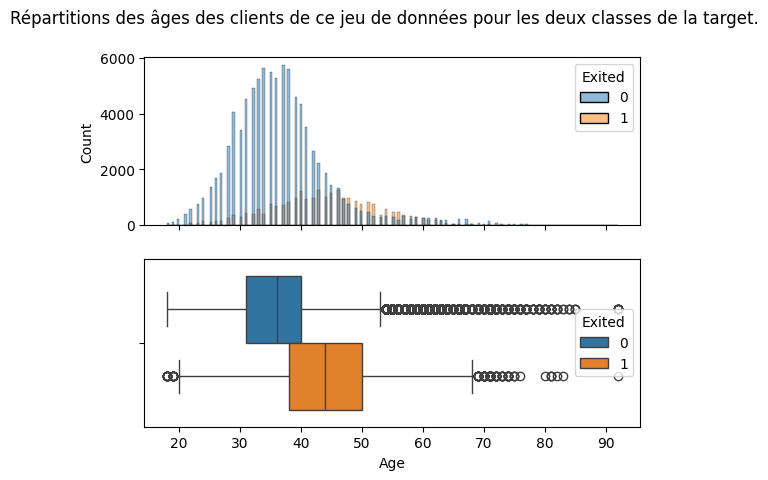

,count,mean,std,min,25%,50%,75%,max
Exited,,,,,,,,
0,90564.0,36.590227,8.166861,18.0,31.0,36.0,40.0,92.0
1,24299.0,43.930368,8.990269,18.0,38.0,44.0,50.0,92.0


In [50]:
fig, ax = plt.subplots(2, 1, sharex=True)
plt.suptitle("Répartitions des âges des clients de ce jeu de données pour les deux classes de la target.")
sns.histplot(data=train_set, x="Age", hue="Exited", ax=ax[0])
sns.boxplot(data=train_set, x="Age", hue="Exited", ax=ax[1])
plt.show()
train_set.groupby("Exited")["Age"].describe()

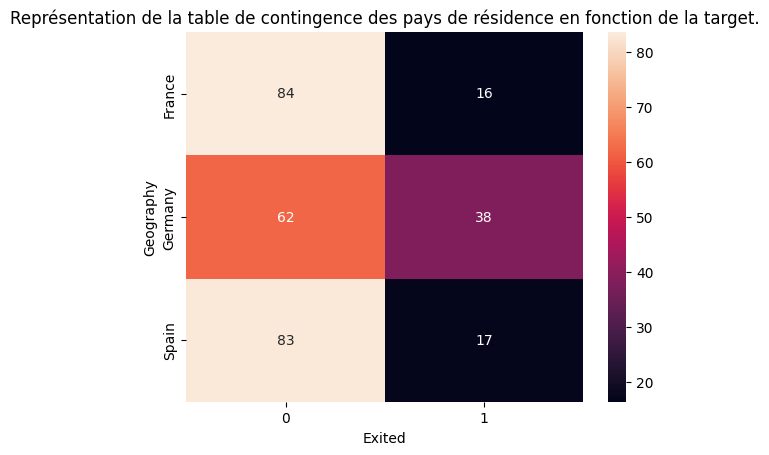

In [51]:
sns.heatmap(pd.crosstab(train_set["Geography"], train_set["Exited"], normalize="index") * 100, annot=True) 
plt.title("Représentation de la table de contingence des pays de résidence en fonction de la target.")
plt.show()

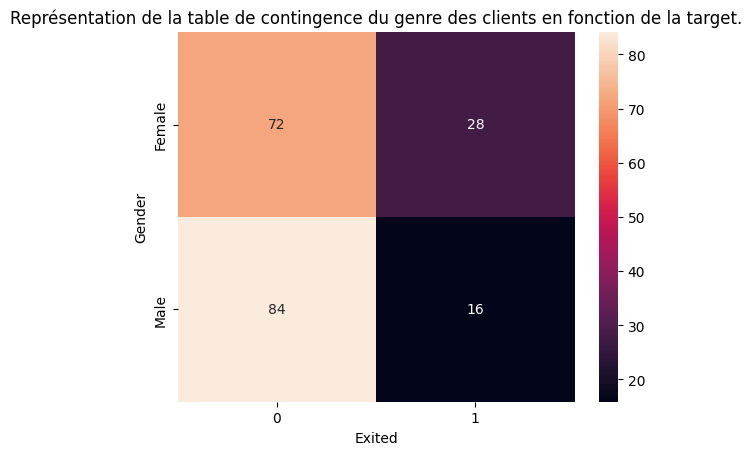

In [52]:
sns.heatmap(pd.crosstab(train_set["Gender"], train_set["Exited"],normalize="index") *100, annot=True)
plt.title("Représentation de la table de contingence du genre des clients en fonction de la target.")
plt.show()

On voit qu'il y a une zone dans lequel on a plus de clients qui ont résilié que de clients qui n'ont pas résilé pour des clients qui ont entre 48 ans et 55 ans. C'est comme si il y avait un décalage entre les deux histogramme. On voit que les boxplots sont différents. On observe deux outliers à gauche de la boxplots des clients qui ont résilié. On voit que les bornes, les différents quartiles ainsi que la médiane sont différentes pour les deux boxplots. On voit que la boxplot pour les clients qui ont résilié est plus étendue que pour les clients qui n'ont pas résilié. On voit que en moyenne les clients qui ont résilié ont 44 ans et les clients qui n'ont pas résilié ont en moyenne 37 ans. Pour le pays de résidence, on voit que le taux de résiliation est plus fort pour les clients qui vive en Allemagne et pour le genre ce sont les femmes qui ont le taus de résiliation le plus fort. On voit des taux de résiliation similaires pour la France et l'Espagne. On peut simplifier cette vairiable en une variable binaire avec oneHotEncoder. On va maintenant tester les hypothéses. 

Conditions pour le test de student:

-L'âge d'un clients ne dépends pas des autres.

-Tous les clients sont issues de la même banque.

-L'âge suit bien une loi normale et on a bien plus de 30 points par classes.

-Les deux variances sont assez similaires pour utiliser un test de student.

In [53]:
print("H0: Les clients qui ont résilié ont en moyenne le même âge que les clients qui n'ont pas résilié.")

alpha = 0.02

p_value = ttest_ind(train_set.query("`Exited` == 0")["Age"], train_set.query("`Exited` == 1")["Age"]).pvalue

if p_value < alpha:
    print("Nous avons assez d'évidence pour rejeter H0")
else:
    print("Nous n'avons pas assez d'évidence pour rejeter H0.")

H0: Les clients qui ont résilié ont en moyenne le même âge que les clients qui n'ont pas résilié.
Nous avons assez d'évidence pour rejeter H0


In [54]:
print("H0: Il n'y a pas de relation entre le pays de résidence et la target.")

alpha = 0.02

p_value = chi2_contingency(pd.crosstab(train_set["Geography"], train_set["Exited"])).pvalue

if p_value < alpha:
    print("Nous avons assez d'évidence pour rejeter H0")
else:
    print("Nous n'avons pas assez d'évidence pour rejeter H0.")

H0: Il n'y a pas de relation entre le pays de résidence et la target.
Nous avons assez d'évidence pour rejeter H0


In [55]:
print("H0: Il n'y a pas de relation entre le genre et la target.")

alpha = 0.02

p_value = chi2_contingency(pd.crosstab(train_set["Gender"], train_set["Exited"])).pvalue

if p_value < alpha:
    print("Nous avons assez d'évidence pour rejeter H0")
else:
    print("Nous n'avons pas assez d'évidence pour rejeter H0.")

H0: Il n'y a pas de relation entre le genre et la target.
Nous avons assez d'évidence pour rejeter H0


Comme on a rejeter H0 pour les trois variables démographique, on peut dire avec un seuil alpha de 2% que les clients qui ont résilié sont en moyenne plus vieux que les clients qui n'ont pas résilié, que le taux de résiliation est plus fort pour les clients qui vive en Allemagne et pour les femmes. On remarque que sur le graphique représentant l'âge, l'âge peut être considéré comme une variable discréte et par conséquent cela peut être judicieux de visualiser l'évolution du taux de résiliation en fonction de l'âge pour voir quels sont les âges avec les plus fort taux de résiliation.

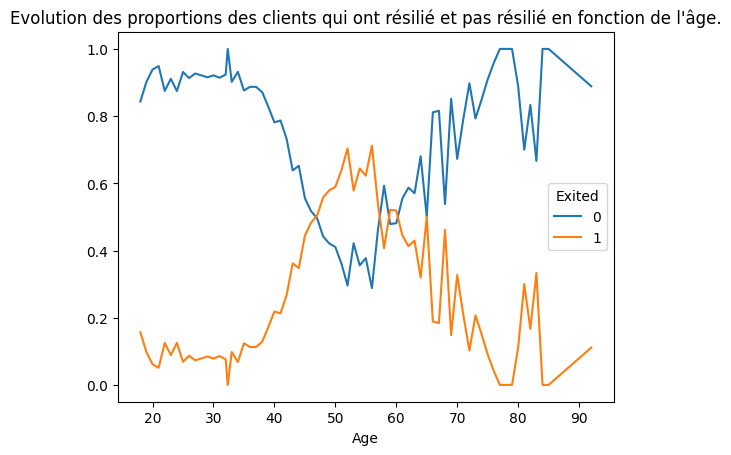

In [56]:
pd.crosstab(train_set["Age"], train_set["Exited"], normalize='index').plot()
plt.title("Evolution des proportions des clients qui ont résilié et pas résilié en fonction de l'âge.")
plt.show()

On remarque qu'il y a principalement quatre zone. Les clients qui ont entre 20 et 40 ans ont un taux de résiliation entre 0 et 20%, ensuite les clients qui ont entre 40 et environ 45 ans ont un taux de résiliation qui augmente jusqu'à atteindre les 50%. Entre 45 et 60 ans on a un taux de résiliation supérieur à 50% avec une petite inversion peu avant 60 ans. Ensuite le taux de résiliation diminue jusqu'à 90 ans. On en conclut que la zone avec le taux de résiliation la plus forte est la zone entre 45 et 60 ans. Il faudrat donc essayer de créer des filtres avec l'âge en faisant une discrétisation des différentes zones.

#II.2.2) Analyse des variables monétaires

Dans les variables monétaires on trouve le score de crédit, la balance et le salaire qui sont tous les trois des variables continues. On va donc faire d'abords une analyse bivarié puis une analyse trivarié avec des surfaces scatter.

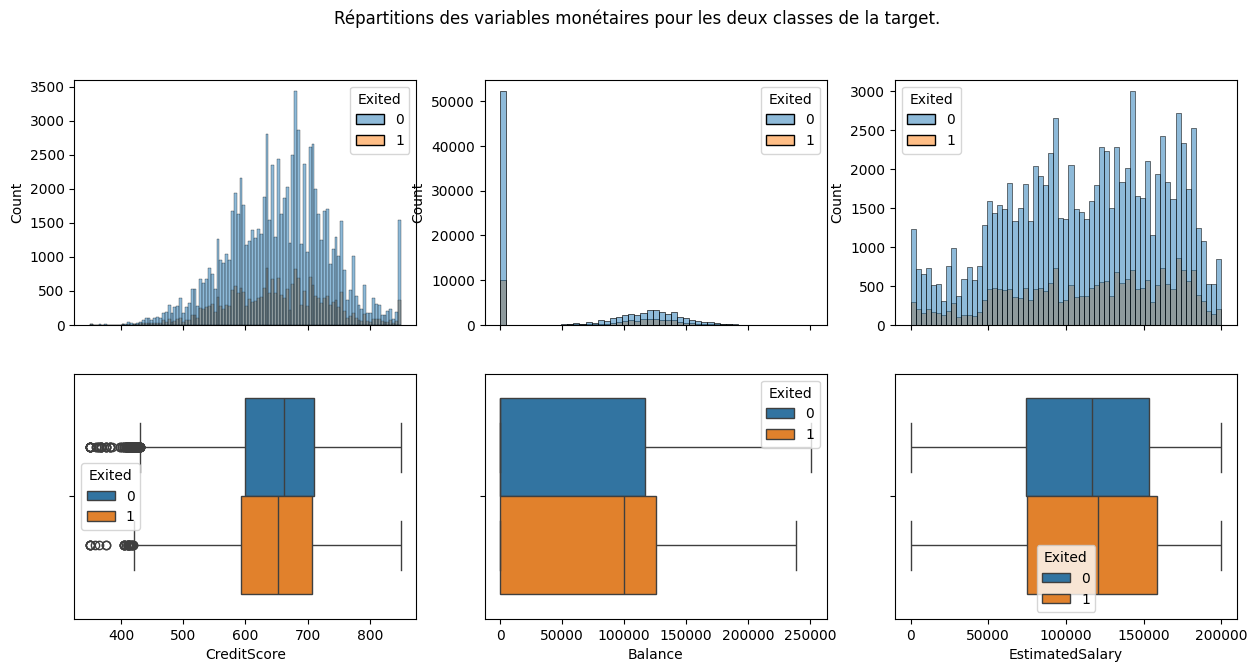

In [57]:
fig, ax = plt.subplots(2, 3, sharex='col')
fig.set_size_inches(15, 7)
plt.suptitle("Répartitions des variables monétaires pour les deux classes de la target.")
sns.histplot(data=train_set, x="CreditScore", hue="Exited", ax=ax[0, 0])
sns.boxplot(data=train_set, x="CreditScore", hue="Exited", ax=ax[1, 0])
sns.histplot(data=train_set, x="Balance", hue="Exited", ax=ax[0, 1])
sns.boxplot(data=train_set, x="Balance", hue="Exited", ax=ax[1, 1])
sns.histplot(data=train_set, x="EstimatedSalary", hue="Exited", ax=ax[0, 2])
sns.boxplot(data=train_set, x="EstimatedSalary", hue="Exited", ax=ax[1, 2])
plt.show()

In [58]:
train_set.groupby("Exited")["CreditScore"].describe()

,count,mean,std,min,25%,50%,75%,max
Exited,,,,,,,,
0,90564.0,657.624652,79.886114,350.0,599.0,662.0,711.0,850.0
1,24299.0,652.327668,81.147985,350.0,593.0,652.0,708.0,850.0


In [59]:
train_set.groupby("Exited")["Balance"].describe() 

,count,mean,std,min,25%,50%,75%,max
Exited,,,,,,,,
0,90564.0,51350.581504,62184.711374,0.0,0.0,0.00,116880.2975,250898.09
1,24299.0,71553.939758,62639.217643,0.0,0.0,99510.89,125717.5750,238387.56


In [60]:
train_set.query("`Balance` != 0").groupby("Exited")["Balance"].describe() 

,count,mean,std,min,25%,50%,75%,max
Exited,,,,,,,,
0,38346.0,121277.683809,25536.140837,3768.69,103913.6900,122328.095,137961.4525,250898.09
1,14272.0,121825.194940,23574.612647,9904.42,106964.6975,122021.920,136487.8600,238387.56


In [61]:
train_set.groupby("Exited")["EstimatedSalary"].describe()

,count,mean,std,min,25%,50%,75%,max
Exited,,,,,,,,
0,90564.0,112058.226740,50193.351699,11.58,74415.8475,116970.50,153667.2175,199992.48
1,24299.0,114087.178014,50640.056773,11.58,74849.8200,120892.96,158427.7950,199992.48


On ne voit aucune séparation entre les deux classes de la target dans les trois histogrammes et pour les trois variables les boxplots des deux classes de la target sont similaires et superposé. On voit que en moyenne les clients qui ont résilié sont moins fiable que les clients qui n'ont pas résilié. On voit une diférence dans les moyennes de balances beaucoup plus grande qui est due au fait qu'il y a une plus petites différences d'effectifs de clients qui ont résilié entre les balances différents de 0 et égale à 0 que ceux qui n'ont pas résilié. Par contre si on prend seulement les balances différents de 0, les moyennes deviennent tous de suites similaires. Pour le salaire, on voit une toutes petites différence. On va maintenant faire des tests d'hypothéses mais comme la balance est une suit une loi normale seulement sans prendre en compte les balance égale à 0, on va faire un test d'hypothése uniquement sur les balance différent de 0 et comme le salaire ne suit pas une loi normale, on ne pourras pas tester l'hypothése avec un test de student. On fera le test dans l'étapes de features engineering aprés correction si possible.

Conditions pour le test de student:

-Le score de crédit et la balance d'un client ne dépends pas des autres.

-Tous les clients sont issues de la même banque.

-Le score de crédit et les balances différents de 0 d'un client suit bien une loi normale et on a bien plus de 30 points par classes.

-Les deux variances pour le score de crédit et les balances différents de 0 sont assez similaires pour utiliser un test de student.

In [62]:
print("H0: Les clients qui ont résilié ont en moyenne le même score de crédit que les clients qui n'ont pas résilié.")

alpha = 0.02

p_value = ttest_ind(train_set.query("`Exited` == 0")["CreditScore"], train_set.query("`Exited` == 1")["CreditScore"]).pvalue

if p_value < alpha:
    print("Nous avons assez d'évidence pour rejeter H0")
else:
    print("Nous n'avons pas assez d'évidence pour rejeter H0.")

H0: Les clients qui ont résilié ont en moyenne le même score de crédit que les clients qui n'ont pas résilié.
Nous avons assez d'évidence pour rejeter H0


In [63]:
print("H0: Les clients qui ont résilié et qui ont une balance différents de 0 ont en moyenne la même balance que les clients qui n'ont pas résilié.")

alpha = 0.02

p_value = ttest_ind(train_set.query("`Exited` == 0 and `Balance` != 0")["Balance"], train_set.query("`Exited` == 1 and `Balance` != 0")["Balance"]).pvalue

if p_value < alpha:
    print("Nous avons assez d'évidence pour rejeter H0")
else:
    print("Nous n'avons pas assez d'évidence pour rejeter H0.")

H0: Les clients qui ont résilié et qui ont une balance différents de 0 ont en moyenne la même balance que les clients qui n'ont pas résilié.
Nous n'avons pas assez d'évidence pour rejeter H0.


On a rejeter l'hypothése H0 pour le score de crédit mais pas pour la balance différent de 0. On peut donc dire avec un seuil alpha de 2% que les clients qui ont résilié sont en moyenne moins fiable que les clients qui n'ont pas résilié et que les clients qui ont résilié et qui ont une balance différents de 0 ont en moyenne la même balance que les clients qui n'ont pas résilié. Malgré qu'il y a une différences dans les moyennes, il n'y a aucune séparation dans les répartitions. On remarque que la boxplot des clients qui ont résilié est légérements décaler vers la gauche par rapport à la boxplots des clients qui n'ont pas résilié. On voit ce décalage avec la borne inférieur, le premier quartile et la médiane puis cette différence diminue avec le troisiéme quartile. C'est-à-dire que la différence est plus forte pour des valeurs inférieur à la médiane. Maintenant comme il y a uniquement des variables continues, on va regarder les surfaces scatter.

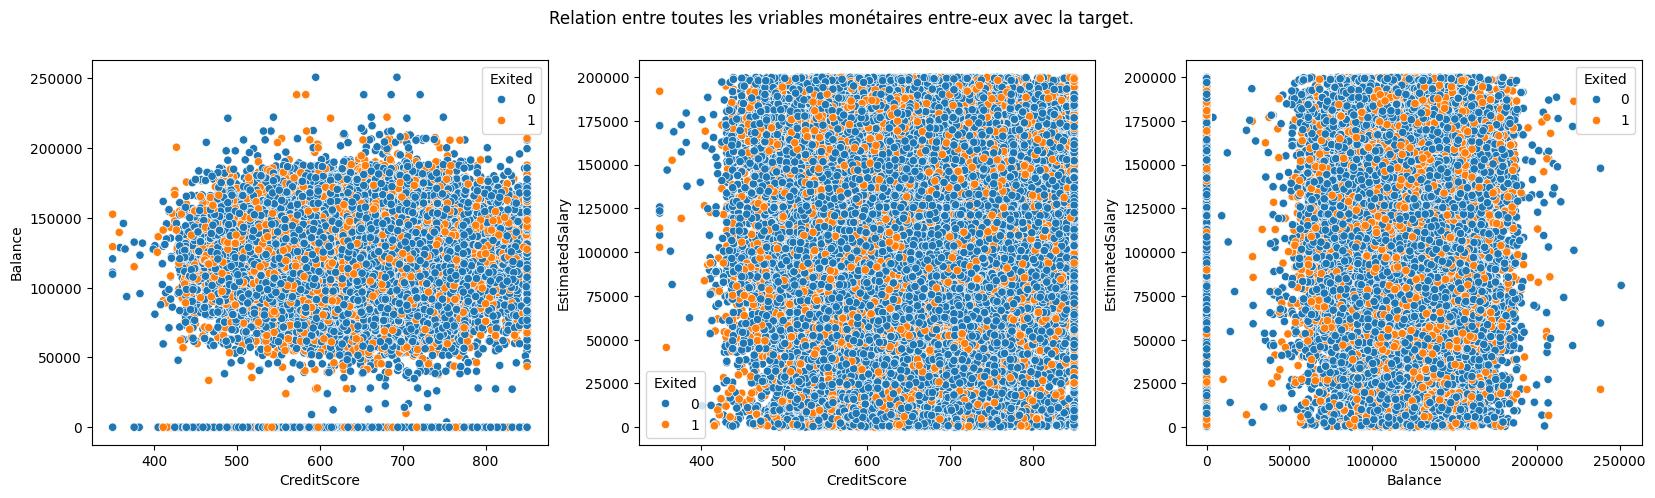

In [64]:
fig, ax = plt.subplots(1, 3)
fig.set_size_inches(20, 5)
plt.suptitle("Relation entre toutes les vriables monétaires entre-eux avec la target.")
sns.scatterplot(data=train_set, x="CreditScore", y="Balance", hue="Exited", ax=ax[0])
sns.scatterplot(data=train_set, x="CreditScore", y="EstimatedSalary", hue="Exited", ax=ax[1])
sns.scatterplot(data=train_set, x="Balance", y="EstimatedSalary", hue="Exited", ax=ax[2])
plt.show()

On ne voit aucune surface séparable.

#II.2.3) Analyse des variables de fidélités

On compte quatre variables de fidélité qui sont la Tenure, le nombre de produit, la possession d'une carte de crédit et lestatus d'activité.

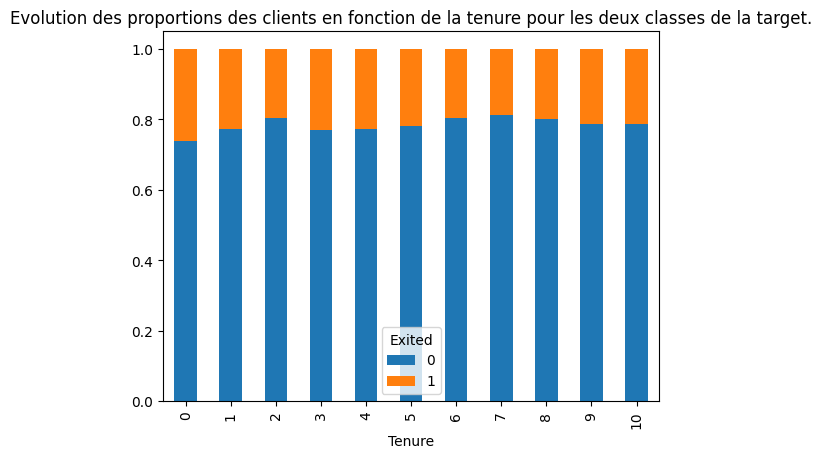

Exited,0,1
Tenure,,
0,0.740300,0.259700
1,0.772097,0.227903
2,0.805434,0.194566
3,0.769837,0.230163
4,0.773422,0.226578
5,0.781776,0.218224
6,0.804463,0.195537
7,0.813334,0.186666
8,0.800686,0.199314


In [65]:
pd.crosstab(train_set["Tenure"], train_set["Exited"], normalize="index").plot(kind="bar", stacked=True)
plt.title("Evolution des proportions des clients en fonction de la tenure pour les deux classes de la target.")
plt.show()

pd.crosstab(train_set["Tenure"], train_set["Exited"], normalize="index")

In [66]:
pd.crosstab(train_set["NumOfProducts"], train_set["Exited"], normalize="index")

Exited,0,1
NumOfProducts,,
1,0.653274,0.346726
2,0.939440,0.060560
3,0.121855,0.878145
4,0.139319,0.860681


In [67]:
pd.crosstab(train_set["HasCrCard"], train_set["Exited"], normalize="index")

Exited,0,1
HasCrCard,,
0.0,0.771947,0.228053
1.0,0.793810,0.206190


In [68]:
pd.crosstab(train_set["IsActiveMember"], train_set["Exited"], normalize="index")

Exited,0,1
IsActiveMember,,
0.0,0.702792,0.297208
1.0,0.875131,0.124869


On voit que le taux de résiliation est maximal pour les clients qui ont un nombre de produit strictement supérieur à 2 et qui ne sont pas actif. On voit que le taux de résiliation est vraiment similaires en fonction de la possession d'une carte de crédit. On voit sur la figure que le taux de résiliation est presque constant en fonction de la tenure. On voit aussi que pour des nombres de produits 3 et 4,  les taux de churn sont similaires et par conséquent on peut simplifier en combinant les nombres de produits 3 et 4. On va maintenant tester les relations.

In [69]:
print("H0: Il n'y a pas de relation entre la tenure et la target.")

alpha = 0.02

p_value = chi2_contingency(pd.crosstab(train_set["Tenure"], train_set["Exited"])).pvalue

if p_value < alpha:
    print("Nous avons assez d'évidence pour rejeter H0")
else:
    print("Nous n'avons pas assez d'évidence pour rejeter H0.")

H0: Il n'y a pas de relation entre la tenure et la target.
Nous avons assez d'évidence pour rejeter H0


In [70]:
print("H0: Il n'y a pas de relation entre le nombre de produit et la target.")

alpha = 0.02

p_value = chi2_contingency(pd.crosstab(train_set["NumOfProducts"], train_set["Exited"])).pvalue

if p_value < alpha:
    print("Nous avons assez d'évidence pour rejeter H0")
else:
    print("Nous n'avons pas assez d'évidence pour rejeter H0.")

H0: Il n'y a pas de relation entre le nombre de produit et la target.
Nous avons assez d'évidence pour rejeter H0


In [71]:
print("H0: Il n'y a pas de relation entre la possession d'une carte de crédit et la target.")

alpha = 0.02

p_value = chi2_contingency(pd.crosstab(train_set["HasCrCard"], train_set["Exited"])).pvalue

if p_value < alpha:
    print("Nous avons assez d'évidence pour rejeter H0")
else:
    print("Nous n'avons pas assez d'évidence pour rejeter H0.")

H0: Il n'y a pas de relation entre la possession d'une carte de crédit et la target.
Nous avons assez d'évidence pour rejeter H0


In [72]:
print("H0: Il n'y a pas de relation entre le status d'activité et la target.")

alpha = 0.02

p_value = chi2_contingency(pd.crosstab(train_set["IsActiveMember"], train_set["Exited"])).pvalue

if p_value < alpha:
    print("Nous avons assez d'évidence pour rejeter H0")
else:
    print("Nous n'avons pas assez d'évidence pour rejeter H0.")

H0: Il n'y a pas de relation entre le status d'activité et la target.
Nous avons assez d'évidence pour rejeter H0


On a rejeter H0 pour toutes les variables de fidélité. Malgré que l'hypothése H0 est rejeter pour la tenure ainsi que pour HasCrCard, le taux de résiliation est presque constant et par conséquent on n'utilisera pas ces deux variables pour le premier modéle.

#II.2.4) Relation entre les variables monétaires et l'âge.

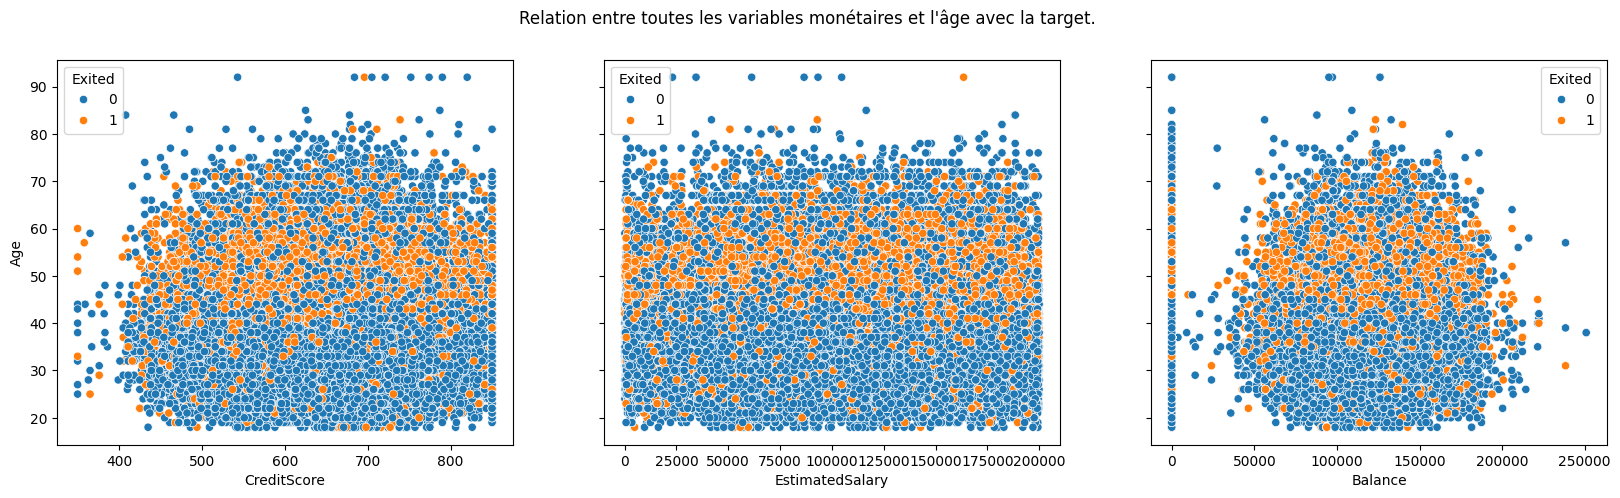

In [73]:
fig, ax = plt.subplots(1, 3, sharey=True)
fig.set_size_inches(20, 5)
plt.suptitle("Relation entre toutes les variables monétaires et l'âge avec la target.")
sns.scatterplot(data=train_set, x="CreditScore", y="Age", hue="Exited", ax=ax[0])
sns.scatterplot(data=train_set, x="EstimatedSalary", y="Age", hue="Exited", ax=ax[1])
sns.scatterplot(data=train_set, x="Balance", y="Age", hue="Exited", ax=ax[2])
plt.show()

On ne voit aucune surface séparable mais on voit que le clients qui ont résilié sont majoritairement dans un intervalles d'âges entre 40 ans et 70 ans qui correspond à la zone du graphique qui montre le taux de résiliation et de non résiliation en fonction de l'age. En conclusion, toutes les variables peuvent être importantes selon les tests d'hypothéses même si avec beaucoup de variables on observe rien d'intéréssant.

#III) Préprocéssing

#III.1) Nettoyage des données

Commençons par le nettoyage des données.

In [74]:
train_set.isna().value_counts()

ID     CustomerId  Surname  CreditScore  Geography  Gender  Age    Tenure  Balance  NumOfProducts  HasCrCard  IsActiveMember  EstimatedSalary  Exited
False  False       False    False        False      False   False  False   False    False          False      False           False            False     114863
Name: count, dtype: int64

On voit qu'il n'y a pas de valeur vide dans le jeu de train. Durant l'analyse précédente on n'a pas vue d'outliers vraiment significatifs.

In [75]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn import set_config
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline
from sklearn.metrics import f1_score

X_train_set = train_set.drop("Exited", axis=1)
y_train_set = train_set["Exited"]
X_test_set = test_set.drop("Exited", axis=1)
y_test_set = test_set["Exited"]
set_config(transform_output='pandas')

#III.2) Encoding

On voit qu'il y a trois variables à encoder qui sont le nom, le pays de résidence et le genre mais on va seulement encoder le pays de résidence et le genre car on supprimera le nom. La variable du genre est une variable binaire et le pays est une variable non ordinal et par conséquent on utilisera seulement un onehot encoder pour les deux variables. On appliquera pas drop first car on va sélectionner à la fin les meilleurs variables.

In [76]:
categorical_column = ["Geography", "Gender"]
encoder = ColumnTransformer(
    [
        ("Encoding_onehot", OneHotEncoder(sparse_output=False, drop='first', handle_unknown="ignore"), categorical_column)
    ],
    remainder="passthrough",
    verbose_feature_names_out=False
)
encoder

ColumnTransformer(remainder='passthrough',
                  transformers=[('Encoding_onehot',
                                 OneHotEncoder(drop='first',
                                               handle_unknown='ignore',
                                               sparse_output=False),
                                 ['Geography', 'Gender'])],
                  verbose_feature_names_out=False)

In [77]:
X_train_set_copy = X_train_set.copy()
column_encoders = encoder.fit_transform(X_train_set_copy)
column_encoders

,Geography_Germany,Geography_Spain,Gender_Male,ID,CustomerId,Surname,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
91348,0.0,0.0,0.0,108635,15606267,Wilson,622,35.0,7,98640.74,2,1.0,1.0,110457.99
2636,0.0,0.0,0.0,147941,15644891,Pirozzi,752,32.0,2,0.00,1,1.0,0.0,159843.24
117007,0.0,0.0,1.0,88744,15702464,Watson,710,31.0,4,0.00,3,0.0,0.0,160548.66
100279,1.0,0.0,1.0,125789,15701605,L?,704,46.0,4,138912.17,1,0.0,1.0,141804.78
34835,1.0,0.0,0.0,135997,15757577,Hs?,675,51.0,8,143390.51,1,1.0,0.0,168034.90
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
110268,0.0,0.0,1.0,90447,15711455,Rivera,850,36.0,1,0.00,2,1.0,1.0,108747.12
119879,0.0,0.0,1.0,52704,15646227,Davis,748,28.0,4,167268.98,1,1.0,0.0,169423.72
103694,0.0,0.0,1.0,58256,15581748,Yermakov,576,37.0,4,0.00,2,1.0,1.0,55868.97
131932,1.0,0.0,0.0,129732,15613471,Brierly,479,43.0,2,90218.11,1,1.0,1.0,102908.91


#III.3) Feature engineering et feature selection

On va créer un transformer personnaliser qui va corriger les salaires en les transformant selon le smic de chaque pays. On va dire que tous les salaires inférieur à 125 euros seront des salaires horaires. Entre 125 et chacun des smic, se serat des salaires journalier. Ensuite de chaque smic mensuel jusqu'à smic * 12. Ce transformer va ensuite faire les simplification de variable décrites dans l'analyse et il va aussi supprimer toutes les variables inutiles.

In [78]:
class CustomTransformer(BaseEstimator, TransformerMixin):
    def __init__(self):
        pass

    def fit(self, X, y=None):
        # Apprendre les paramètres à partir de X si nécessaire
        return self

    def transform(self, X, y=None):
        condition_list = [
            
            #Salaire horaire
            (X["EstimatedSalary"] < 125) & (X["Geography_Germany"] == 0) & (X["Geography_Spain"] == 0),
            (X["EstimatedSalary"] < 125) & (X["Geography_Germany"] == 1),
            (X["EstimatedSalary"] < 125) & (X["Geography_Spain"] == 1),
            
            #Salaire journalier
            (X["Geography_Germany"] == 0) & (X["Geography_Spain"] == 0) & (X["EstimatedSalary"] >= 125) & (X["EstimatedSalary"] < 1709),
            (X["Geography_Germany"] == 1) & (X["EstimatedSalary"] >= 125) & (X["EstimatedSalary"] < 2200),
            (X["Geography_Spain"] == 1) & (X["EstimatedSalary"] >= 125) & (X["EstimatedSalary"] < 1167),
            
            #Salaire mensuel
            ((X["Geography_Germany"] == 0) & (X["Geography_Spain"] == 0) & (X["EstimatedSalary"] >= 1709) & (X["EstimatedSalary"] < 1709 * 12)) |
            ((X["Geography_Germany"] == 1) & (X["EstimatedSalary"] >= 2200) & (X["EstimatedSalary"] < 2200 * 12)) |
            ((X["Geography_Spain"] == 1) & (X["EstimatedSalary"] >= 1167) & (X["EstimatedSalary"] < 1167 * 12))
        ]
        choicelist = [1607, 1832, 1826, 230, 229, 228, 12]
        X["EstimatedSalary"] *= np.select(condition_list, choicelist, default = 1)
        X["NumOfProducts"] = X["NumOfProducts"].replace(
            {
                4 : 3
            }
        )
        X = X.drop(["Surname", "ID", "CustomerId", "Tenure", "HasCrCard", "Geography_Spain"], axis=1)
        return X

In [79]:
feature_transformer = make_pipeline(CustomTransformer())
feature_transformer

Pipeline(steps=[('customtransformer', CustomTransformer())])

In [80]:
column_feature = feature_transformer.fit_transform(column_encoders)
column_feature

,Geography_Germany,Gender_Male,CreditScore,Age,Balance,NumOfProducts,IsActiveMember,EstimatedSalary
91348,0.0,0.0,622,35.0,98640.74,2,1.0,110457.99
2636,0.0,0.0,752,32.0,0.00,1,0.0,159843.24
117007,0.0,1.0,710,31.0,0.00,3,0.0,160548.66
100279,1.0,1.0,704,46.0,138912.17,1,1.0,141804.78
34835,1.0,0.0,675,51.0,143390.51,1,0.0,168034.90
...,...,...,...,...,...,...,...,...
110268,0.0,1.0,850,36.0,0.00,2,1.0,108747.12
119879,0.0,1.0,748,28.0,167268.98,1,0.0,169423.72
103694,0.0,1.0,576,37.0,0.00,2,1.0,55868.97
131932,1.0,0.0,479,43.0,90218.11,1,1.0,102908.91


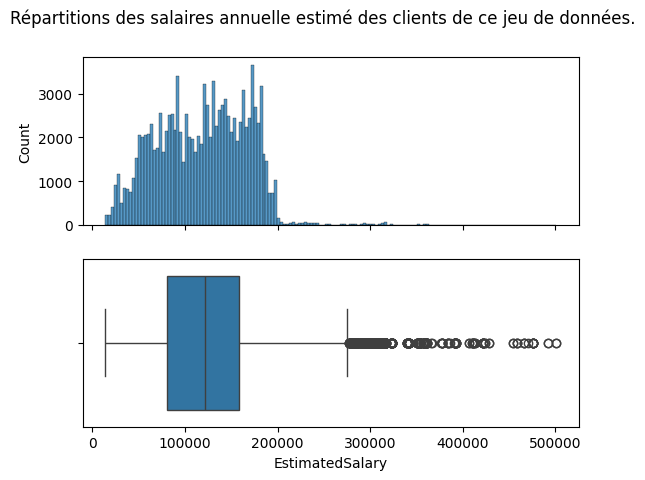

count    114863.000000
mean     119237.533738
std       48969.273327
min       14032.620000
25%       80825.900000
50%      121747.960000
75%      158742.090000
max      500784.070000
Name: EstimatedSalary, dtype: float64

In [81]:
fig, ax = plt.subplots(2, 1, sharex=True)
plt.suptitle("Répartitions des salaires annuelle estimé des clients de ce jeu de données.")
sns.histplot(data=column_feature, x="EstimatedSalary", ax=ax[0])
sns.boxplot(data=column_feature, x="EstimatedSalary", ax=ax[1])
plt.show()
column_feature["EstimatedSalary"].describe()

On voit que maintenant on a une distribution qui ressemble un peu plus à une loi normale. On vois que les salaires annuelle sont majoritairement inférieur à 200000 euros par an. Ensuite on des outliers au dlà de 200000 euros par ans. On va maintenant visualiser les répartitions du salaire annuelle en fonction de la target.

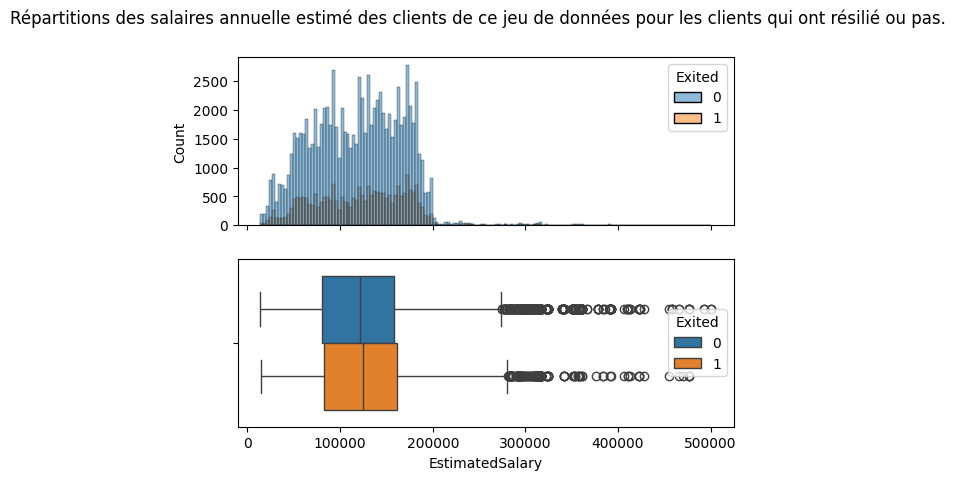

,count,mean,std,min,25%,50%,75%,max
Exited,,,,,,,,
0,90564.0,118628.517074,48767.314821,14032.62,80553.96,121345.42,157939.53,500784.07
1,24299.0,121507.379622,49650.008874,14073.41,82522.61,124777.14,161435.02,476136.80


In [82]:
fig, ax = plt.subplots(2, 1, sharex=True)
plt.suptitle("Répartitions des salaires annuelle estimé des clients de ce jeu de données pour les clients qui ont résilié ou pas.")
sns.histplot(data=column_feature, x="EstimatedSalary", hue = y_train_set, ax=ax[0])
sns.boxplot(data=column_feature, x="EstimatedSalary", hue = y_train_set, ax=ax[1])
plt.show()
column_feature.groupby(y_train_set)["EstimatedSalary"].describe()

On a des répartitions similaires pour les deux classes de la target et les deux moyennes sont assez similaires avec quand même une différences. On va donc faire un test de student. Regardons d'abords les conditions. Le salaires d'un client ne dépends pas des autres. Tous les clients sont issues de la même banque et il y a plus de 30 points par groupes et les variances sont assez proche pour utiliser un test de student.

In [83]:
hypthesis_test_set = column_feature.copy()
hypthesis_test_set["Exited"] = y_train_set
print("H0: Les clients qui ont résilié ont en moyenne le même salaire annuelle que les clients qui n'ont pas résilié.")

alpha = 0.02

p_value = ttest_ind(hypthesis_test_set.query("`Exited` == 0")["EstimatedSalary"], hypthesis_test_set.query("`Exited` == 1")["EstimatedSalary"]).pvalue

if p_value < alpha:
    print("Nous avons assez d'évidence pour rejeter H0")
else:
    print("Nous n'avons pas assez d'évidence pour rejeter H0.")

H0: Les clients qui ont résilié ont en moyenne le même salaire annuelle que les clients qui n'ont pas résilié.
Nous avons assez d'évidence pour rejeter H0


Comme l'hypothése H0 à été rejeter on peut donc dire avec un seuil alpha de 2% que les deux moyennes sont bien significativement différents.

#III.4) Normalisation

On va utiliser minmax avec toutes les variables discrétes.

In [85]:
normalizer = ColumnTransformer(
    [
        ("standard", StandardScaler(), ["Age", "CreditScore", "EstimatedSalary"]),
        ("MinMax", MinMaxScaler(), ["NumOfProducts", "Geography_Germany", "IsActiveMember", "Gender_Male", "Balance", "Geography_Spain"])
    ],
    remainder="passthrough",
    verbose_feature_names_out=False
)
normalizer

ColumnTransformer(remainder='passthrough',
                  transformers=[('standard', StandardScaler(),
                                 ['Age', 'CreditScore', 'EstimatedSalary']),
                                ('MinMax', MinMaxScaler(),
                                 ['NumOfProducts', 'Geography_Germany',
                                  'IsActiveMember', 'Gender_Male', 'Balance',
                                  'Geography_Spain'])],
                  verbose_feature_names_out=False)

In [86]:
final_column = normalizer.fit_transform(column_feature)
final_column

ValueError: A given column is not a column of the dataframe

In [ ]:
pipeline = make_pipeline(encoder, feature_transformer, selecter, normalizer)
pipeline

/home/florian/anaconda3/envs/bank_churn_project_env/lib/python3.11/site-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('columntransformer-1',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('Encoding_onehot',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['Geography', 'Gender'])],
                                   verbose_feature_names_out=False)),
                ('pipeline',
                 Pipeline(steps=[('customtransformer', CustomTransformer())])),
                ('selectkbest', SelectKBest()),
                ('columntransformer-2',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('standard', StandardScaler(),
                                                  ['Age', 'CreditScore',
                                                   'EstimatedSalary']),
                                                 ('MinMax', MinMaxScaler(),
                                                  ['NumOfProducts',
                                                   'Geography_Germany',
                                                   'IsActiveMember',
                                                   'Gender_Male', 'Balance',
                                                   'Geography_Spain'])],
                                   verbose_feature_names_out=False))])

In [ ]:
train_set_finale = pipeline.fit_transform(X_train_set, y_train_set)
train_set_finale

,Age,CreditScore,EstimatedSalary,NumOfProducts,Geography_Germany,IsActiveMember,Gender_Male,Balance,Geography_Spain,HasCrCard
91348,-0.354355,-0.430316,-0.179288,0.333333,0.0,1.0,0.0,0.393151,0.0,1.0
2636,-0.692585,1.190972,0.829211,0.000000,0.0,0.0,0.0,0.000000,0.0,1.0
117007,-0.805328,0.667171,0.843617,0.666667,0.0,0.0,1.0,0.000000,0.0,0.0
100279,0.885823,0.592342,0.460847,0.000000,1.0,1.0,1.0,0.553660,0.0,0.0
34835,1.449541,0.230671,0.996494,0.000000,1.0,0.0,0.0,0.571509,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...
110268,-0.241611,2.413173,-0.214225,0.333333,0.0,1.0,1.0,0.000000,0.0,1.0
119879,-1.143559,1.141086,1.024855,0.000000,0.0,0.0,1.0,0.666681,0.0,1.0
103694,-0.128868,-1.004002,-1.294053,0.333333,0.0,1.0,1.0,0.000000,0.0,1.0
131932,0.547593,-2.213732,-0.333448,0.000000,1.0,1.0,0.0,0.359581,0.0,1.0


#IV) Modélisation

Pour ce projet on va tester DecisionTreeClassifier.

In [ ]:
model = DecisionTreeClassifier()
param_grid = {
    'criterion': ['gini', 'entropy', 'log_loss'],
    'max_depth': [None, 5, 10, 20, 30, 40, 50],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 10],
    'max_features': [None, 'sqrt', 'log2', 'auto'],
    'splitter': ['best', 'random']
}

grisearch = GridSearchCV(estimator=model, param_grid=param_grid, cv=5, scoring="f1")
grisearch.fit(train_set_finale, y_train_set)
print(grisearch.best_params_)
print(grisearch.best_score_)
#0.6255206680676496

{'criterion': 'gini', 'max_depth': 10, 'max_features': None, 'min_samples_leaf': 2, 'min_samples_split': 10, 'splitter': 'random'}
0.6255206680676496


/home/florian/anaconda3/envs/bank_churn_project_env/lib/python3.11/site-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
3360 fits failed out of a total of 13440.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
3360 fits failed with the following error:
Traceback (most recent call last):
  File "/home/florian/anaconda3/envs/bank_churn_project_env/lib/python3.11/site-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/home/florian/anaconda3/envs/bank_churn_project_env/lib/python3.11/site-packages/sklearn/base.py", line 1382, in wrapper
    estimator._validate_params()
  File "/home/florian/anaconda3/envs/bank_churn_project_env/lib/p

In [ ]:
X_test_set = pipeline.transform(X_test_set)
best_model = grisearch.best_estimator_
y_pred = best_model.predict(X_test_set)
test_f1 = f1_score(y_test_set, y_pred)
test_f1
#0.631820687121073

/home/florian/anaconda3/envs/bank_churn_project_env/lib/python3.11/site-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


0.631820687121073

In [ ]:
kaggle_test_set = pd.read_csv("test_data.csv")
kaggle_test_set.head()

,ID,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,67897,15585246,Bancks,585,France,Female,53.0,2,0.00,2,1.0,1.0,91830.75
1,163075,15604551,Robb,606,France,Male,24.0,2,0.00,1,0.0,1.0,90876.95
2,134760,15729040,Ugochukwu,633,Germany,Male,44.0,1,118907.60,1,1.0,0.0,47777.15
3,68707,15792329,Hs?,602,Germany,Male,40.0,2,149961.99,2,1.0,1.0,82696.84
4,3428,15617166,Genovesi,645,France,Male,31.0,4,132351.29,1,1.0,0.0,151887.16


In [ ]:
kaggle_test_set_finale = pipeline.transform(kaggle_test_set)
kaggle_test_set_finale

/home/florian/anaconda3/envs/bank_churn_project_env/lib/python3.11/site-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


,Age,CreditScore,EstimatedSalary,NumOfProducts,Geography_Germany,IsActiveMember,Gender_Male,Balance,Geography_Spain
0,1.675028,-0.891759,-0.559676,0.333333,0.0,1.0,0.0,0.000000,0.0
1,-1.594533,-0.629859,-0.579153,0.000000,0.0,1.0,1.0,0.000000,0.0
2,0.660337,-0.293130,-1.459297,0.000000,1.0,0.0,1.0,0.473928,0.0
3,0.209363,-0.679744,-0.746200,0.333333,1.0,1.0,1.0,0.597701,0.0
4,-0.805328,-0.143473,0.666740,0.000000,0.0,0.0,1.0,0.527510,0.0
...,...,...,...,...,...,...,...,...,...
21450,-0.354355,0.355385,1.140208,0.333333,0.0,1.0,1.0,0.000000,0.0
21451,0.998567,-0.106058,0.764629,0.000000,0.0,0.0,0.0,0.000000,1.0
21452,-0.692585,-0.617387,1.110126,0.333333,0.0,1.0,0.0,0.000000,0.0
21453,2.013258,0.604814,0.862619,0.000000,0.0,0.0,0.0,0.000000,0.0


In [ ]:
best_model = grisearch.best_estimator_

ypred = best_model.predict(kaggle_test_set_finale)
ypred

array([0, 0, 1, ..., 0, 1, 0])

In [ ]:
results = pd.DataFrame(
    {
        "ID": kaggle_test_set["ID"],
        "Exited": ypred
    }
)
results.set_index("ID")

,Exited
ID,
67897,0
163075,0
134760,1
68707,0
3428,0
...,...
24790,0
152608,1
28134,0


In [ ]:
results.to_csv("submission.csv")

Avec ce premier modéle avec seulement un seleckBest() sans features enginering (à par la correction du salaire) on arrive à avoir sur le set de kaggle une performance de 62.630%. Pour le deuxiéme modéle on feras une analyse fondamentale basé sur le domaine pour chercher des variables qu'on peut calculer à partir des variables existantes. 